## Clases Base

In [1]:
#!pip install torch --index-url https://download.pytorch.org/whl/cu121
#!pip -q install -U transformers accelerate sentencepiece bitsandbytes huggingface_hub

In [2]:
!pip install dotenv
!pip install sentencepiece

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

class Node:
    def __init__(self, full_text: str, token: str, puntaje: float, profundidad: int = 0, probabilidad_actual=1):
        self.full_text = full_text
        self.token = token
        self.children = []
        self.score = puntaje
        self.profundidad = profundidad
        self.probabilidad_actual = probabilidad_actual

    def agregar_hijo(self, nodo):
        self.children.append(nodo)

    def show(self):
        grafo = nx.DiGraph()

        def recorrer(nodo: Node):
            nodo_id = id(nodo)

            grafo.add_node(nodo_id, label=nodo.token.replace("\n", "\\n"))

            for hijo in nodo.children:
                recorrer(hijo)
                grafo.add_edge(nodo_id, id(hijo), weight=f"{hijo.score:.3f}")

        recorrer(self)

        def calcular_posiciones(nodo):
            posiciones = {}
            def asignar(nodo, profundidad, x_actual):
                nodo_id = id(nodo)
                if len(nodo.children) == 0:
                    posiciones[nodo_id] = (x_actual[0], -profundidad)
                    x_actual[0] += 1
                    return posiciones[nodo_id][0]
                xs_hijos = []
                for hijo in nodo.children:
                    xs_hijos.append(asignar(hijo, profundidad + 1,x_actual))

                x = sum(xs_hijos) / len(xs_hijos)
                posiciones[nodo_id] = (x, -profundidad)
                return x

            asignar(nodo, 0, [0])
            return posiciones

        pos = calcular_posiciones(self)
        plt.figure(figsize=(16, 10))

        labels = nx.get_node_attributes(grafo, "label")
        edge_labels = nx.get_edge_attributes(grafo, "weight")
        nx.draw(
            grafo,
            pos,
            labels=labels,
            node_size=2500,
            font_size=8,
            arrows=True
        )

        nx.draw_networkx_edge_labels(
            grafo,
            pos,
            edge_labels=edge_labels,
            font_size=7
        )

        plt.title("Árbol de generación")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

In [4]:
from huggingface_hub import login
import os
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

class ModelFactory:
    def __init__(self):
        load_dotenv()

        login_token = os.getenv("HUGGING_FACE_TOKEN")
        if login_token is None:
            raise ValueError("Recuerda que debes agregar un archivo .env al entorno.")

        login(token=login_token)

        self.model_name = "mistralai/Mistral-7B-Instruct-v0.3"

    def get_model(self):
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            quantization_config=quantization_config,
            device_map="auto",
        )
        return model

    def get_tokenizer(self):
        tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        return tokenizer

In [5]:
import numpy as np
import torch


class SuccesorGenerator:
    _instancia = None

    def __new__(cls):
        if cls._instancia is None:
            cls._instancia = super().__new__(cls)
        return cls._instancia

    def __init__(self):
        if hasattr(self, '_inicializado'):
            return
        model_factory = ModelFactory()
        self.model = model_factory.get_model()
        self.tokenizer = model_factory.get_tokenizer()

    def _decode_token(self, indice: int) -> str:
        if int(indice) == self.tokenizer.eos_token_id:
            return "<eos>"

        token = self.tokenizer.convert_ids_to_tokens([int(indice)])[0]
        text = token.replace("▁", " ")
        return text

    def _get_probabilities(self, input: str) -> np.ndarray:
        """
        Devuelve las probabilidades del vocabulario para el próximo token
        como un numpy.ndarray.
        """
        inputs = self.tokenizer(
            input,
            return_tensors="pt"
        )
        inputs = {k: v.to(self.model.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits[:, -1, :]
            probs = torch.softmax(logits, dim=-1)

        return probs.squeeze(0).to(torch.float32).cpu().numpy()

    def get_succesors_best_k(self, input:str, k: int):
        """
        Devuelve una lista de tamaño k de la forma

        [
            [probabilidad, string_del_token],
            [probabilidad, string_del_token],
            [probabilidad, string_del_token],
        ]
        con los k resultados de mayor probabilidad.
        """
        token_probabilities = self._get_probabilities(input)
        # Índices de los k mayores, ordenados de mayor a menor
        idx = np.argpartition(token_probabilities, -k)[-k:]
        idx = idx[np.argsort(token_probabilities[idx])[::-1]]

        return [
            [
                float(token_probabilities[indice]),
                self._decode_token(indice)
            ]
            for indice in idx
        ]

    def get_sucesors_p_min(self, input: str, min_p: float, n: int):
        """
        Devuelve un sampleo sin reposición de n tokens entre aquellos cuya
        probabilidad supera min_p, siguiendo probabilidades renormalizadas
        y ordenados de mayor a menor probabilidad original.

        Si tras el filtro hay menos de n tokens disponibles, retorna todos.

        [
            [probabilidad, string_del_token],
            [probabilidad, string_del_token],
            [probabilidad, string_del_token],
        ]
        """
        probs = self._get_probabilities(input)

        # Paso 1: filtrar por min_p
        indices = np.where(probs >= min_p)[0]

        # Si hay menos candidatos que n, retornar todos ordenados
        if len(indices) <= n:
            indices = indices[np.argsort(probs[indices])[::-1]]
            return [
                [
                    float(probs[i]),
                    "<eos>" if int(i) == self.tokenizer.eos_token_id
                    else self.tokenizer.decode([int(i)])
                ]
                for i in indices
            ]

        # Paso 2: renormalizar probabilidades para que sumen 1
        filtered_probs = probs[indices]
        renormalized_probs = filtered_probs / filtered_probs.sum()

        # Paso 3: sampleo sin reposición de n tokens
        sampled_positions = np.random.choice(
            len(indices),
            size=n,
            replace=False,
            p=renormalized_probs
        )
        sampled_indices = indices[sampled_positions]

        # Ordenar de mayor a menor probabilidad original
        sampled_indices = sampled_indices[np.argsort(probs[sampled_indices])[::-1]]

        return [
            [
                float(probs[i]),
                self._decode_token(i)
            ]
            for i in sampled_indices
        ]

# Actividades

In [6]:

import math


def generic_beam_search(nodo_raiz: Node, generador: SuccesorGenerator, profundidad: int, k: int, lambda_fuction):    
    beam = [nodo_raiz]
    for _ in range(profundidad):
        candidatos = []
        for nodo in beam:
            k_mejores = lambda_fuction(generador, nodo, k)
            for probabilidad, token in k_mejores:
                hijo = crear_y_agregar_hijo(nodo, token, probabilidad)
                candidatos.append(hijo)
        if len(candidatos) == 0:
            break
        beam = sorted(candidatos, key=lambda nodo: nodo.score, reverse=True)[:k]
        # Condicion de termino: si el mejor candidato es <eos>, detenerse
        if beam[0].token == "<eos>":
            break
    return beam[0]





def crear_y_agregar_hijo(nodo_padre: Node, token: str, probabilidad: float) -> Node:
    # TODO
    nueva_profundidad = nodo_padre.profundidad + 1
    score_acumulado = nodo_padre.score * nodo_padre.profundidad + math.log10(probabilidad)
    score_normalizado = score_acumulado / nueva_profundidad
    nodo_hijo = Node(nodo_padre.full_text + token, token, score_normalizado, nueva_profundidad, probabilidad_actual=probabilidad)
    nodo_padre.agregar_hijo(nodo_hijo)
    return nodo_hijo

def greedy_search(nodo_padre: Node, generador: SuccesorGenerator, profundidad: int) -> Node:
    return generic_beam_search(nodo_padre, generador, profundidad, 1,
                               lambda generador, nodo, k: generador.get_succesors_best_k(nodo.full_text, k))

def beam_search(nodo_raiz: Node, generador: SuccesorGenerator, profundidad: int, k: int) -> Node:
    # TODO
    return generic_beam_search(nodo_raiz, generador, profundidad, k, 
                        lambda generador, nodo, k: generador.get_succesors_best_k(nodo.full_text, k)
                        )

def p_min_beam_search(nodo_padre: Node, generador: SuccesorGenerator, profundidad: int, p_min: float, beam_size:int):
    # TODO
    return generic_beam_search(nodo_padre, generador, profundidad, beam_size, 
                        lambda generador, nodo, beam_size: generador.get_sucesors_p_min(nodo.full_text, p_min, beam_size)
                        )

def p_min_generation(nodo_padre: Node, generador: SuccesorGenerator, profundidad: int, p_min: float):
    # TODO
    return p_min_beam_search(nodo_padre, generador, profundidad, p_min, 1)


def random_sampling_generation(nodo_padre: Node, generador: SuccesorGenerator, profundidad: int) -> Node:
    # TODO
    return generic_beam_search(nodo_padre, generador, profundidad, 1,
                               lambda generador, nodo, k: generador.get_sucesors_p_min(nodo.full_text, 0, k))


def recursive_k_sucesors(nodo_padre: Node, generador: SuccesorGenerator, profundidad: int, k: int = 3) -> Node:
    # TODO
    if profundidad <= 0:
        return nodo_padre

    k_mejores = generador.get_succesors_best_k(nodo_padre.full_text, k)

    if not k_mejores:
        return nodo_padre

    mejores_hojas = []
    for probabilidad, token in k_mejores:
        hijo = crear_y_agregar_hijo(nodo_padre, token, probabilidad)
        mejor_hoja = recursive_k_sucesors(hijo, generador, profundidad - 1, k)
        mejores_hojas.append(mejor_hoja)

    return max(mejores_hojas, key=lambda nodo: nodo.score)

def beam_search_custom(nodo_padre: Node, generador: SuccesorGenerator, profundidad:int):
    raise NotImplementedError("Aún se implementa esta función")


In [7]:
generador = SuccesorGenerator()

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /home/diegoftpxd/.cache/huggingface/token
Login successful


/mnt-homes/wapol/asoto/diegoftpxd/miniforge3/envs/openvla/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

/mnt-homes/wapol/asoto/diegoftpxd/miniforge3/envs/openvla/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [8]:
from typing import List, Tuple
import math

# La idea es 

# 1) Generar el vector de predicción
# 2) Tomar los k más probables

# 3) ¿De alguna forma agregar ruido al vector de predicción?
#   Idea: Agregar ruido gausseano a la última capa del transformer
#   y generar una nueva muestra ¿deberia mantener parte importante del significado?

# 4) Quedarme con los k más probables y luego muestrear según su estimación.


def normalizar_por_logprobabilidad_acumulada(beam: List[Node]) -> List[Tuple[Node, float]]:
    max_score = max(nodo.score for nodo in beam)
    # Como score está en log10, convertimos restando el máximo (equivalente a softmax en base 10)
    pesos_no_normalizados = [10 ** (nodo.score - max_score) for nodo in beam]
    suma = sum(pesos_no_normalizados)
    return [(nodo, peso / suma) for nodo, peso in zip(beam, pesos_no_normalizados)]

def filtro_particula_search(beam: List[Node], generador: SuccesorGenerator, k: int = 10, n: int = 3):
    """
    Retorno n nodos
    Expando k nodos en cada paso
    """
    beam_probabilidades = normalizar_por_logprobabilidad_acumulada(beam)
    resultados: List[Node] = []
    for nodo, pr in beam_probabilidades:
        k_mios = math.ceil(pr * k)
        muestra = generador.get_sucesors_p_min(nodo.full_text, 0, k_mios)
        for probabilidad, token in muestra:
            hijo = crear_y_agregar_hijo(nodo, token, probabilidad)
            resultados.append(hijo)
    
    resultados.sort(key=lambda x: x.score, reverse=True)
    mejor = resultados[0]
    # Condicion de termino
    if mejor.token == "<eos>":
        return mejor
    # Seguir buscando
    return filtro_particula_search(resultados[:n], generador, k, n)





# Test de uso

Aquí se muestra un pequeño ejemplo de como debería llamarse a las funciones de busqueda. Puedes usar el método show para poder visualizar si la estructura del arbol coincide con lo esperado según el algoritmo de busqueda.

In [9]:
prompt = "How are you? \n"


How are you? 
<0x0A><0x0A><0x0A>I'm just a computer program, so I don't have feelings or emotions. I'm here to help you with any questions or problems you might have. How can I assist you today?<0x0A><0x0A>If you have any questions or need help with something specific, please let me know and I'll do my best to help you. If you just want to chat, I'm happy to do that too!<0x0A><0x0A>Is there something specific you'd like to talk about or ask about?<eos><eos><eos>
-0.11610454177336431
118


/tmp/ipykernel_842354/802383563.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


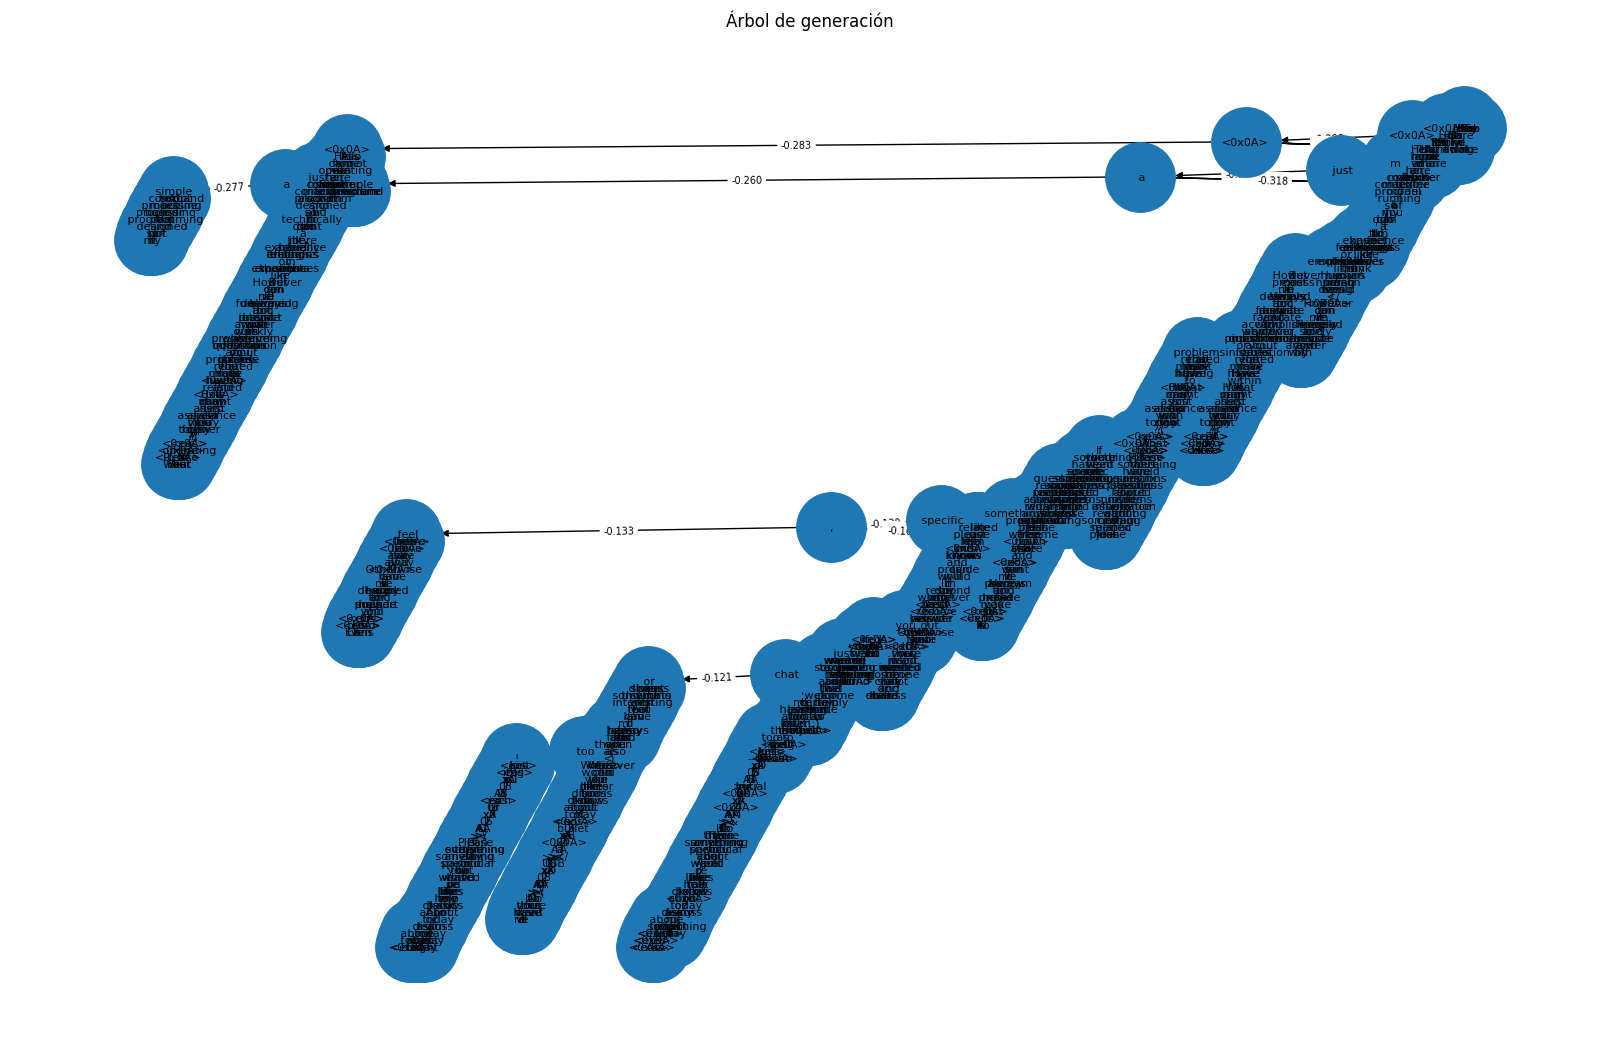

In [10]:
# Crear la raíz con el texto inicial
nodo_raiz = Node(full_text=prompt, token="", puntaje=0.0)

# Correr la búsqueda
#mejor_nodo = beam_search(nodo_raiz, generador, profundidad, 3)

mejor_nodo = filtro_particula_search([nodo_raiz], generador)

# Ver el resultado
print(mejor_nodo.full_text)
print(mejor_nodo.score)
print(mejor_nodo.profundidad)
nodo_raiz.show()


## Comparacion algoritmos

La idea es que ahora compares como se comportan distintos algoritmos ante el siguiente prompt.

How are you? 
<0x0A><0x0A><0x0A>I'm just a computer program, so I don't have feelings or emotions. I'm here to help you with any questions or problems you might have. How can I assist you today?<0x0A><0x0A>If you have any questions or need help with something specific, please let me know and I'll do my best to help you. If you just want to chat, I'm happy to do that too!<0x0A><0x0A>Is there something specific you'd like to talk about or ask about?<eos><eos><eos>
-0.11610454177336431
118


/tmp/ipykernel_842354/802383563.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


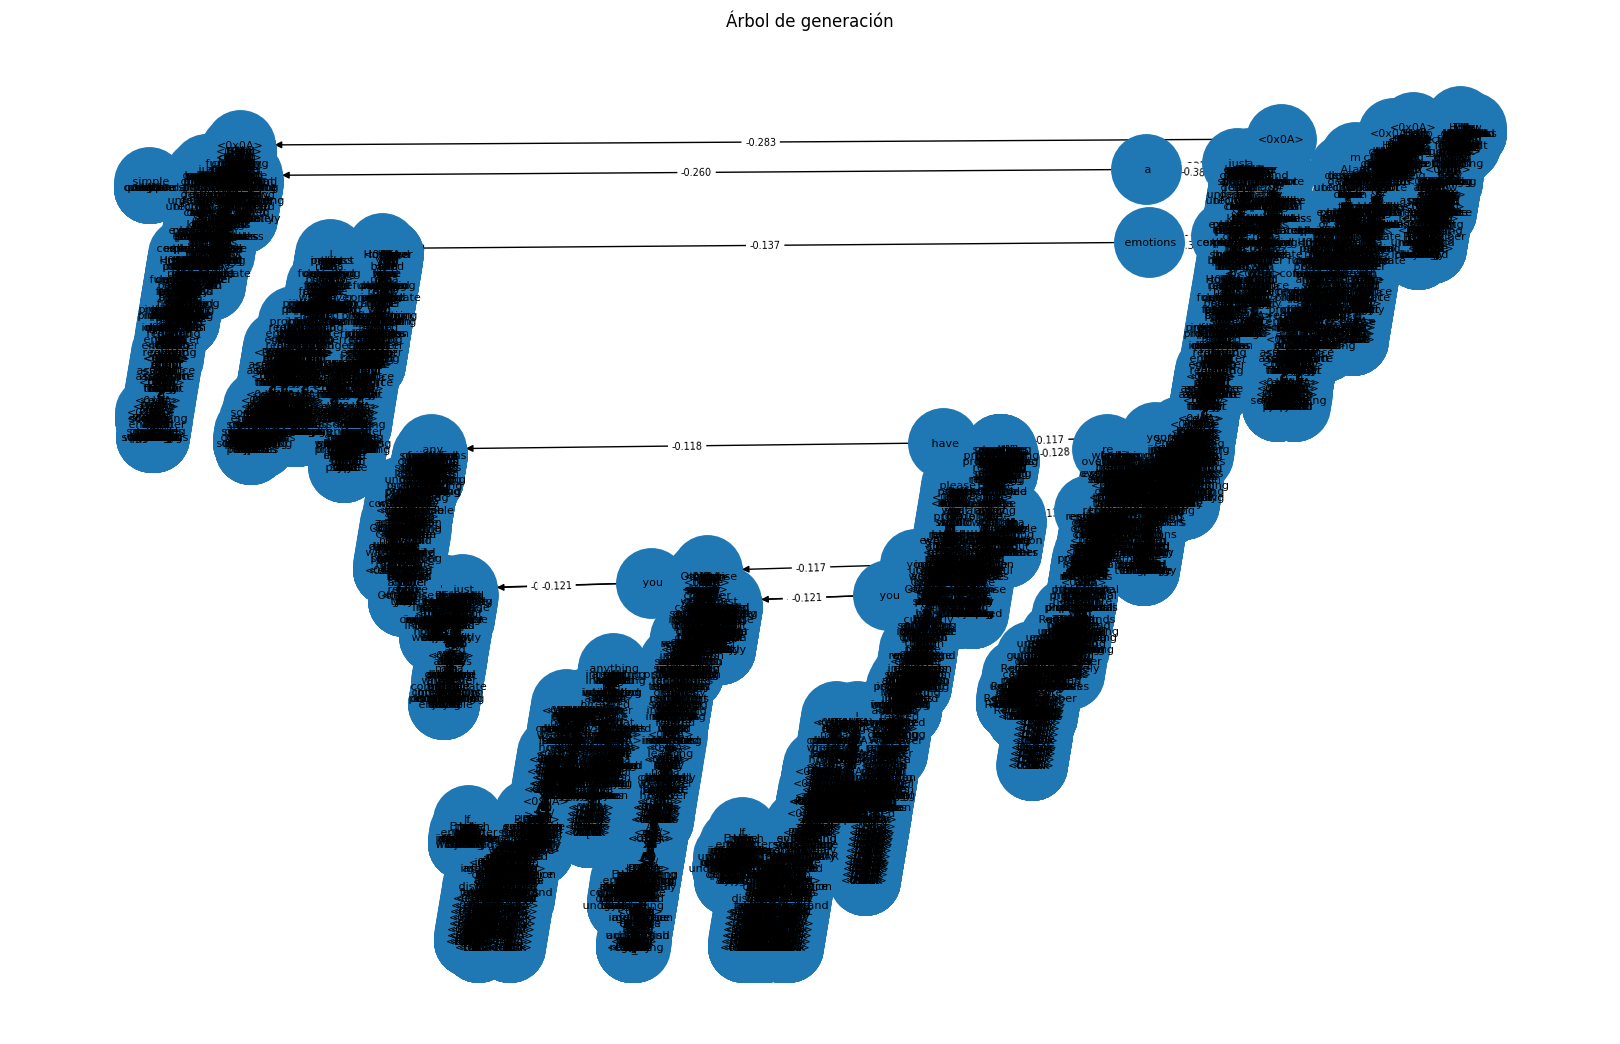

In [11]:
nodo_raiz = Node(full_text=prompt, token="", puntaje=0.0)

beam_search(nodo_raiz, generador, 100000000000, 10)

# Ver el resultado
print(mejor_nodo.full_text)
print(mejor_nodo.score)
print(mejor_nodo.profundidad)
nodo_raiz.show()